# Installing required dependencies

You may skip this step if done previously!

In [ ]:
!pip install numpy==1.23.4
!pip install scipy==1.9.3
!pip install jax==0.4.33
!pip install cachetools==4.2.1
!pip install dp_accounting
!pip install tensorflow_privacy
!pip install tensorflow_compression
!pip install tensorflow_model_optimization
!pip install pyfarmhash
!pip install google-vizier
!pip install mkl-fft==1.3.6
!pip install tensorflow-federated

# Add Imports

In [1]:
import tensorflow_federated as tff
import numpy as np
import pandas as pd
import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

2025-03-18 11:45:10.982967: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-18 11:45:11.414676: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-03-18 11:45:11.414755: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-03-18 11:45:11.416301: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-18 11:45:11.653558: I tensorflow/core/platform/cpu_feature_g

# Load the dataset

In [2]:
df = pd.read_csv("combined_dataset.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 310734 entries, 0 to 310733
Data columns (total 36 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   H_L0.1_weight          310734 non-null  float64
 1   H_L0.01_weight         310734 non-null  float64
 2   H_L0.01_mean           310734 non-null  float64
 3   H_L0.01_variance       310734 non-null  float64
 4   HH_L3_covariance       310734 non-null  float64
 5   HH_L3_pcc              310734 non-null  float64
 6   HH_L1_std              310734 non-null  float64
 7   HH_L1_radius           310734 non-null  float64
 8   HH_L1_covariance       310734 non-null  float64
 9   HH_L1_pcc              310734 non-null  float64
 10  HH_L0.1_std            310734 non-null  float64
 11  HH_L0.1_radius         310734 non-null  float64
 12  HH_L0.1_covariance     310734 non-null  float64
 13  HH_L0.1_pcc            310734 non-null  float64
 14  HH_L0.01_std           310734 non-nu

In [5]:
df.head()

,H_L0.1_weight,H_L0.01_weight,H_L0.01_mean,H_L0.01_variance,HH_L3_covariance,HH_L3_pcc,HH_L1_std,HH_L1_radius,HH_L1_covariance,HH_L1_pcc,...,HpHp_L0.1_radius,HpHp_L0.1_pcc,HpHp_L0.01_weight,HpHp_L0.01_std,HpHp_L0.01_magnitude,HpHp_L0.01_radius,HpHp_L0.01_covariance,HpHp_L0.01_pcc,type,client_id
0,0.719713,0.977143,0.244441,0.121552,0.40019,0.465515,0.0,0.0,0.375233,0.457158,...,0.0,0.447814,0.0,0.0,2.081668e-17,0.0,0.57339,0.470035,4,1
1,0.725959,0.904079,0.244149,0.121682,0.40019,0.465515,0.0,0.0,0.375233,0.457158,...,0.0,0.447814,0.0,0.0,2.081668e-17,0.0,0.57339,0.470035,4,1
2,0.707341,0.866662,0.243959,0.121766,0.40019,0.465515,0.0,0.0,0.375233,0.457158,...,0.0,0.447814,0.0,0.0,2.081668e-17,0.0,0.57339,0.470035,4,1
3,0.728029,0.776828,0.243877,0.121802,0.40019,0.465515,0.0,0.0,0.375233,0.457158,...,0.0,0.447814,0.0,0.0,2.081668e-17,0.0,0.57339,0.470035,4,1
4,0.718801,0.975166,0.244186,0.121666,0.40019,0.465515,0.0,0.0,0.375233,0.457158,...,0.0,0.447814,0.0,0.0,2.081668e-17,0.0,0.57339,0.470035,4,1


# Visualizing the dataset

<AxesSubplot: title={'center': 'Class Distribution'}>

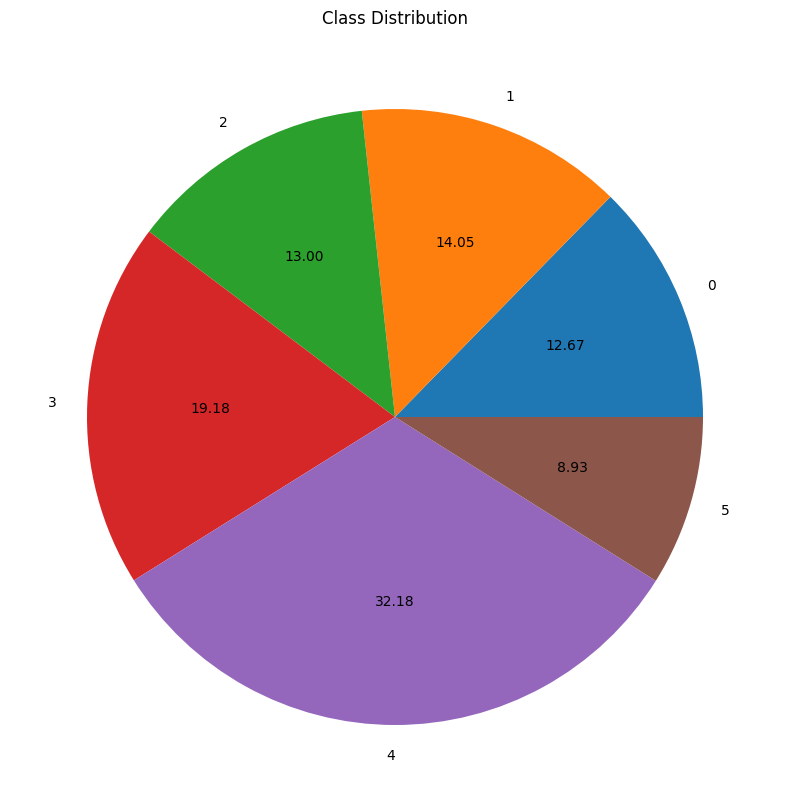

In [4]:
from matplotlib import pyplot as plt

plt.title("Class Distribution")
df.groupby("type").size().plot(kind='pie', autopct='%.2f', figsize=(20,10))

# Data Distribution among clients
Code written logically to discard certain attack labels from certain clients

In [7]:
from sklearn.model_selection import train_test_split

# Assuming `df` contains features, target (`type`), and `client_id`)
X = df.drop(columns=['type', 'client_id'])  
y = df['type']
client_ids = df['client_id']

# Split dataset (80% training, 20% testing) while preserving client_id alignment
X_train, X_test, y_train, y_test, client_train_ids, client_test_ids = train_test_split(
    X, y, client_ids, test_size=0.2, random_state=42, stratify=y
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

# Convert Pandas DataFrame to TensorFlow Dataset
def create_tf_dataset(X, y):
    dataset = tf.data.Dataset.from_tensor_slices((X.values, y.values))
    dataset = dataset.shuffle(buffer_size=len(X)).batch(20)  # Adjust batch size if needed
    return dataset

def create__tf_dataset(X, y):
    dataset = tf.data.Dataset.from_tensor_slices((X.values, y.values))
    dataset = dataset.shuffle(buffer_size=len(X)).batch(6)  # Adjust batch size if needed
    return dataset

# Group data by client_id to ensure logical data split
def create_federated_data(X, y, client_ids):
    federated_data = []
    unique_clients = client_ids.unique()
    
    for client in unique_clients:
        client_X = X[client_ids == client]
        client_y = y[client_ids == client]
        federated_data.append(create_tf_dataset(client_X, client_y))
    
    return federated_data

# Create federated datasets
train_dataset = create_tf_dataset(X_train, y_train)
test_dataset = create__tf_dataset(X_test, y_test)

# Simulate federated client datasets
NUM_CLIENTS = 5  # Adjust based on your needs

client_data = create_federated_data(X_train, y_train, client_train_ids)

Train shape: (248587, 34), Test shape: (62147, 34)


# Visualizing the Client-Data Distribution

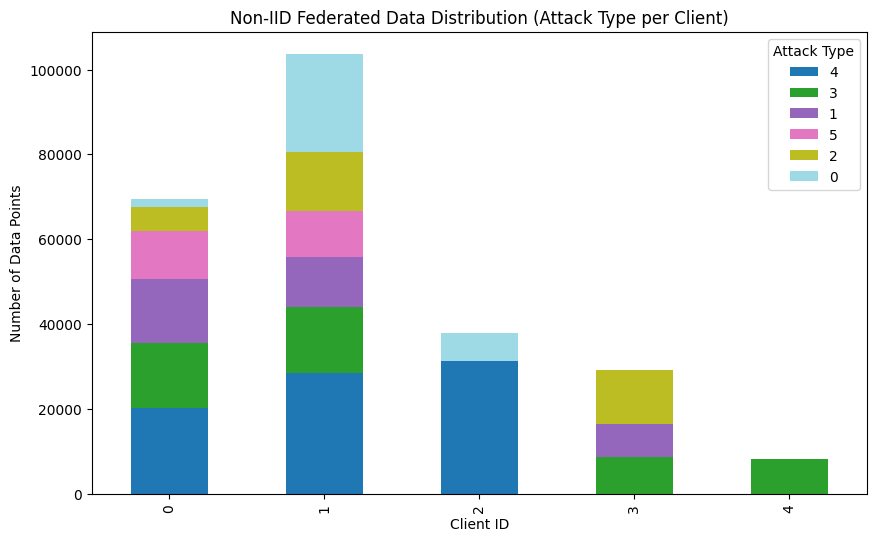

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Visualization of Non-IID Data Distribution
def visualize_federated_data(client_data, y_train, client_train_ids):
    client_distribution = {}

    # Extract class counts per client
    for i, dataset in enumerate(client_data):
        y_values = np.concatenate([y.numpy() for _, y in dataset])
        class_counts = pd.Series(y_values).value_counts().to_dict()
        client_distribution[i] = class_counts

    # Convert to DataFrame for plotting
    dist_df = pd.DataFrame(client_distribution).fillna(0).astype(int)

    # Plotting
    dist_df.T.plot(
        kind='bar', 
        stacked=True, 
        figsize=(10, 6),
        colormap='tab20'
    )

    plt.title('Non-IID Federated Data Distribution (Attack Type per Client)')
    plt.xlabel('Client ID')
    plt.ylabel('Number of Data Points')
    plt.legend(title='Attack Type')
    plt.show()

visualize_federated_data(client_data, y_train, client_train_ids)
